<div style="
    background: #0f3460;
    padding: 14px 48px;
    border-left: 5px solid #e94560;
    font-family: 'Segoe UI', sans-serif;
    width: 100vw;
    box-sizing: border-box;
    position: relative;
    left: 50%;
    transform: translateX(-50%);
    overflow: hidden;
">
    <p style="color: rgba(255,255,255,0.5); font-size: 0.75em; margin: 0 0 4px 0;
       letter-spacing: 2px; text-transform: uppercase;">
        Nhập môn học máy &nbsp;|&nbsp; Báo cáo Đồ án 3 &nbsp;|&nbsp; CQ2023/24
    </p>
    <div style="display: flex; align-items: baseline; gap: 20px; flex-wrap: wrap;">
        <div>
            <h1 style="color: #ffffff; font-size: 1.4em; margin: 0 0 2px 0; font-weight: 700;">
                Notebook: MNIST Rotation Invariance
            </h1>
            <p style="color: #89b4fa; font-size: 0.88em; margin: 0;">
                2D Digit Recognition · Baseline CNN · Data Augmentation · Frame Averaging
            </p>
        </div>
        <span style="color: rgba(255,255,255,0.5); font-size: 0.8em; margin-left: auto; white-space: nowrap;">
            10 classes &nbsp;·&nbsp; 3 models &nbsp;·&nbsp; MNIST dataset
        </span>
    </div>
</div>


## Table of Contents

- [1. Chuẩn bị Dữ liệu (Dataset & DataLoader)](#1-chuẩn-bị-dữ-liệu-dataset--dataloader)
  - [1.1 Hiển thị một số dữ liệu minh họa](#11-hiển-thị-một-số-dữ-liệu-minh-họa)
- [2. Định nghĩa Mô hình CNN (SimpleCNN)](#2-định-nghĩa-mô-hình-cnn-simplecnn)
- [3. Hàm Huấn luyện (Training Loop)](#3-hàm-huấn-luyện-training-loop)
  - [3.1 Huấn luyện Mô hình Baseline](#31-huấn-luyện-mô-hình-baseline)
  - [3.2 Huấn luyện Mô hình Data Augmentation](#32-huấn-luyện-mô-hình-data-augmentation)
  - [3.3 Huấn luyện Mô hình Frame Averaging](#33-huấn-luyện-mô-hình-frame-averaging)
- [4. Lưu Trọng số Mô hình](#4-lưu-trọng-số-mô-hình)


Notebook này hướng dẫn chi tiết quá trình huấn luyện hai biến thể của mô hình Mạng Nơ-ron Chập (CNN) trên tập dữ liệu MNIST:

1. **Baseline CNN**: Huấn luyện trên ảnh MNIST gốc.

2. **Data Augmentation CNN**: Huấn luyện trên ảnh MNIST được xoay ngẫu nhiên.

Sau đó, file trọng số (`.pth`) sẽ được lưu lại để phục vụ cho Backend API sử dụng tính năng **Frame Averaging**.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Cấu hình thiết bị (GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")


Đang sử dụng thiết bị: cpu


## **1. Chuẩn bị Dữ liệu (Dataset & DataLoader)**
Ta sẽ tải tập MNIST từ `torchvision`. Với Data Augmentation, ta định nghĩa thêm một Transform xoay ảnh ngẫu nhiên từ 0 đến 360 độ.


In [ ]:
# Phép biến đổi cơ bản cho Baseline
transform_baseline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Phép biến đổi Tăng cường dữ liệu (Data Augmentation)
transform_augmented = transforms.Compose([
    transforms.RandomRotation(180), # Xoay ngẫu nhiên -180 đến 180 độ
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Tải Dataset
trainset_baseline = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_baseline)
trainloader_baseline = torch.utils.data.DataLoader(trainset_baseline, batch_size=64, shuffle=True)

trainset_augmented = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_augmented)
trainloader_augmented = torch.utils.data.DataLoader(trainset_augmented, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_baseline)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)


### **1.1 Hiển thị một số dữ liệu minh họa**


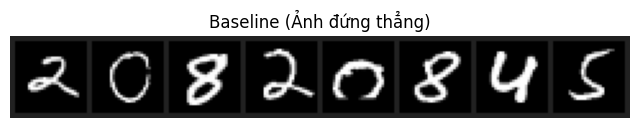

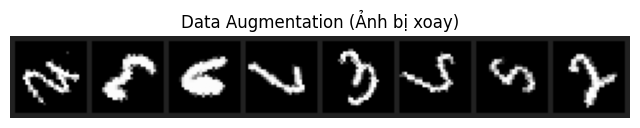

In [ ]:
def imshow(img, title):
    img = img * 0.3081 + 0.1307     # unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(8, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Hiển thị ảnh Baseline
dataiter = iter(trainloader_baseline)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:8]), "Baseline (Ảnh đứng thẳng)")

# Hiển thị ảnh Data Augmentation
dataiter_aug = iter(trainloader_augmented)
images_aug, labels_aug = next(dataiter_aug)
imshow(torchvision.utils.make_grid(images_aug[:8]), "Data Augmentation (Ảnh bị xoay)")


## **2. Định nghĩa Mô hình CNN (SimpleCNN)**
Ta sử dụng một mạng CNN rất đơn giản gồm 2 lớp tích chập (Convolution) và 2 lớp tuyến tính (Fully Connected). Kiến trúc này sẽ được dùng chung cho cả Baseline và Data Augmentation.


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2) # 28x28 -> 28x28
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(2) # 28x28 -> 14x14
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2) # 14x14 -> 14x14
        self.fc1 = nn.Linear(32 * 7 * 7, 128) # Sau maxpool lần 2 là 7x7
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.maxpool(self.relu(self.conv1(x)))
        x = self.maxpool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7) # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("Kiến trúc mô hình:")
print(SimpleCNN())


Kiến trúc mô hình:
SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## **3. Hàm Huấn luyện (Training Loop)**


In [ ]:
def train_model(model, trainloader, epochs=3):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            if i % 300 == 299:    # print every 300 mini-batches
                print(f'[Epoch {epoch + 1}, Batch {i + 1:5d}] loss: {running_loss / 300:.3f}')
                running_loss = 0.0
    print('Huấn luyện hoàn tất!')
    return model


### **3.1 Huấn luyện Mô hình Baseline**


In [ ]:
print("Bắt đầu huấn luyện BASELINE MODEL...")
model_baseline = SimpleCNN()
model_baseline = train_model(model_baseline, trainloader_baseline, epochs=3)


Bắt đầu huấn luyện BASELINE MODEL...
[Epoch 1, Batch   300] loss: 0.315
[Epoch 1, Batch   600] loss: 0.087
[Epoch 1, Batch   900] loss: 0.067
[Epoch 2, Batch   300] loss: 0.043
[Epoch 2, Batch   600] loss: 0.047
[Epoch 2, Batch   900] loss: 0.042
[Epoch 3, Batch   300] loss: 0.031
[Epoch 3, Batch   600] loss: 0.033
[Epoch 3, Batch   900] loss: 0.034
Huấn luyện hoàn tất!


### **3.2 Huấn luyện Mô hình Data Augmentation**


In [ ]:
print("\nBắt đầu huấn luyện AUGMENTED MODEL...")
model_augmented = SimpleCNN()
model_augmented = train_model(model_augmented, trainloader_augmented, epochs=3)



Bắt đầu huấn luyện AUGMENTED MODEL...
[Epoch 1, Batch   300] loss: 0.960
[Epoch 1, Batch   600] loss: 0.439
[Epoch 1, Batch   900] loss: 0.314
[Epoch 2, Batch   300] loss: 0.250
[Epoch 2, Batch   600] loss: 0.227
[Epoch 2, Batch   900] loss: 0.195
[Epoch 3, Batch   300] loss: 0.182
[Epoch 3, Batch   600] loss: 0.165
[Epoch 3, Batch   900] loss: 0.162
Huấn luyện hoàn tất!


### **3.3 Huấn luyện Mô hình Frame Averaging**
Chúng ta xây dựng `FrameAveragingCNN` để bọc lấy `SimpleCNN`. Trong quá trình huấn luyện, mô hình này sẽ tự động phân tích PCA để trích xuất khung (4 góc quay) cho mỗi ảnh, quay ảnh, và tính trung bình Logits. Khi đó, `SimpleCNN` (Backbone) sẽ được học cách nhận diện hình ảnh từ tất cả các góc quay của khung.


In [ ]:
import math
import torchvision.transforms.functional as TF

def get_pca_angles_batch(images):
    B = images.shape[0]
    angles = torch.zeros(B, device=images.device)
    for i in range(B):
        img = images[i, 0]
        threshold = 0.2
        y_indices, x_indices = torch.where(img > threshold)
        if len(x_indices) < 2:
            angles[i] = 0.0
            continue
            
        x_coords = x_indices.float()
        y_coords = y_indices.float()
        
        x_mean = torch.mean(x_coords)
        y_mean = torch.mean(y_coords)
        x_centered = x_coords - x_mean
        y_centered = y_coords - y_mean
        
        coords = torch.stack([x_centered, y_centered], dim=0)
        cov_matrix = torch.matmul(coords, coords.T) / (len(x_coords) - 1)
        
        eigenvalues, eigenvectors = torch.linalg.eigh(cov_matrix)
        principal_vector = eigenvectors[:, 1]
        
        angle_rad = torch.atan2(principal_vector[1], principal_vector[0])
        angle_deg = math.degrees(angle_rad.item())
        angles[i] = angle_deg
    return angles

class FrameAveragingCNN(nn.Module):
    def __init__(self, backbone):
        super(FrameAveragingCNN, self).__init__()
        self.backbone = backbone
        
    def forward(self, x):
        B = x.shape[0]
        angles = get_pca_angles_batch(x)
        
        rotated_images = []
        for i in range(B):
            base_angle = -angles[i].item()
            for offset in [0, 90, 180, 270]:
                rot_img = TF.rotate(x[i], base_angle + offset)
                rotated_images.append(rot_img)
        
        rotated_batch = torch.stack(rotated_images, dim=0)
        
        logits = self.backbone(rotated_batch)
        
        logits = logits.view(B, 4, 10)
        avg_logits = torch.mean(logits, dim=1)
        
        return avg_logits


In [ ]:
print("\nBắt đầu huấn luyện FRAME AVERAGING MODEL...")
backbone_fa = SimpleCNN()
model_frame = FrameAveragingCNN(backbone_fa)
model_frame = train_model(model_frame, trainloader_baseline, epochs=3)



Bắt đầu huấn luyện FRAME AVERAGING MODEL...
[Epoch 1, Batch   300] loss: 0.769
[Epoch 1, Batch   600] loss: 0.250
[Epoch 1, Batch   900] loss: 0.173
[Epoch 2, Batch   300] loss: 0.123
[Epoch 2, Batch   600] loss: 0.109
[Epoch 2, Batch   900] loss: 0.103
[Epoch 3, Batch   300] loss: 0.085
[Epoch 3, Batch   600] loss: 0.074
[Epoch 3, Batch   900] loss: 0.076
Huấn luyện hoàn tất!


## **4. Lưu Trọng số Mô hình**
Lưu các file `.pth` vào thư mục `backend/models` để FastAPI có thể sử dụng.


In [ ]:
import os
from pathlib import Path
# Auto-detect if cwd is the project root or the notebook dir
cwd = Path(os.getcwd())
backend_dir = None
for p in [cwd, cwd / '..', cwd / '../..', cwd / '../../..']:
    resolved = p.resolve()
    if (resolved / 'backend' / 'main.py').exists():
        backend_dir = resolved / 'backend'
        break
if backend_dir is not None:
    models_dir = str((backend_dir / '../storage/weights').resolve())
else:
    models_dir = '../storage/weights'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
torch.save(model_baseline.state_dict(), os.path.join(models_dir, 'model_baseline.pth'))
torch.save(model_augmented.state_dict(), os.path.join(models_dir, 'model_augmented.pth'))
torch.save(model_frame.backbone.state_dict(), os.path.join(models_dir, 'model_frame.pth'))
print("Đã lưu model_baseline.pth, model_augmented.pth, và model_frame.pth thành công vào backend/models!")


Đã lưu model_baseline.pth, model_augmented.pth, và model_frame.pth thành công vào backend/models!
